In [31]:
import numpy as np
import pandas as pd
#import umap
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
from anndata import AnnData


Here I load the spatial data, which consists of the protein intensity per cell, and the geometry location of the cell. I use the cell type annotation from AnnoSpat

read intensities ( protein level per cell)

In [30]:
intensities = pd.read_csv('./processed_files/all_data_intensities.csv',index_col=0)
intensities['ROI'] = pd.to_numeric(intensities.ROI.str[-3:])#make ROI numeric
columns_to_extract = intensities.columns.difference(['ROI', 'source_file'])
intensities_protein = intensities[columns_to_extract]#contains only numeric values (intensities)

The variable`regions` contains the spatial properties of the cells. Cell geometry and location is obtained from ilastik and CellProfiler

In [3]:
regions = pd.read_csv('./processed_files/all_data_regions.csv',index_col=0)
regions.head()

,area,centroid-0,centroid-1,major_axis_length,minor_axis_length,eccentricity,source_file
0,16,1.500000,1.500000,4.472136,4.472136,0.000000,Leap002_003
1,26,1.730769,6.346154,6.458965,5.156497,0.602197,Leap002_003
2,73,2.082192,15.698630,16.540737,5.932868,0.933460,Leap002_003
3,62,1.838710,35.532258,14.916095,5.917155,0.917950,Leap002_003
4,23,0.956522,45.608696,9.966303,3.081719,0.950993,Leap002_003


cell type annotation comes from AnnoSpat

In [ ]:
labels = pd.read_csv('output/trte_labels_ELM_IMC_T1D_AnnoSpat.csv')
num_labels = pd.read_csv('output/trte_labels_numericLabels_ELM_IMC_T1D_AnnoSpat.csv')
mapper = dict(zip(num_labels.label,labels.label))#convert numeric labels to cell types


Using the analysis of [squidpy](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_read_spatial.html) 

In [36]:
adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
adata.obs['AnnoSpat'] = num_labels.label.values.astype(str)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata,n_comps=25)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)


<ipython-input-36-3f5283ad38b4>:1: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


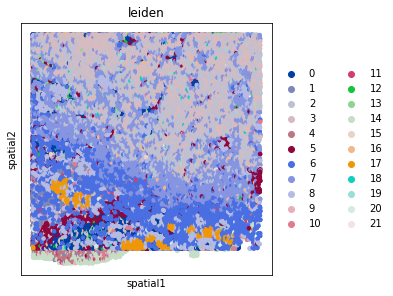

In [34]:
sq.pl.spatial_scatter(adata, shape=None, color="leiden", size=50)


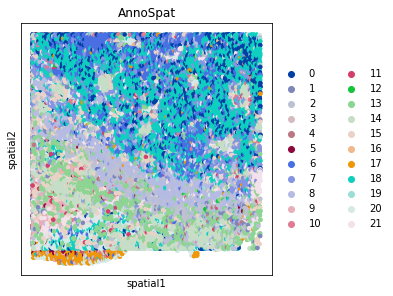

In [48]:
sq.pl.spatial_scatter(adata, shape=None, color="AnnoSpat", size=50)


mapping from cell type label to name

In [54]:
pd.DataFrame.from_dict(mapper,orient='index',columns=['Cell_type']).sort_index()#for AnnoSpat, this is the mapping from cell type label to name

,Cell_type
0,Cancer
1,CD163p_Mac [M2]
2,CD163n_Mac [M1]
3,Naive CD4 T cells
4,Memory T cells
5,Regulatory T cells
6,Naive CD8 T cells
7,Memory CD8 T cells
8,Naive B cells
9,Memory B cells


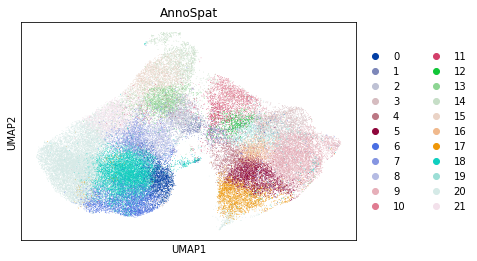

In [53]:
sc.pl.umap(adata,color='AnnoSpat')